# TRAS - C70 Quenched

### Mounting the google drive

In [ ]:
# To begin, we import some libraries that we will need later.

# Some handy standard python libraries
import os

# The numpy library is very useful for many things
import numpy as np
import pandas as pd

# The pyplot module from matplotlib will allow us to plot things.
from matplotlib import pyplot as plt
from scipy.optimize import curve_fit
from math import pi

In [ ]:
# Connect (mount) your google drive as a virtual directory accessible by this python code.
from google.colab import drive         # Import the python module that allows you to access your google drive
rootpathdrive = '/content/drive'       # This will be the directory as which your google drive will be known
drive.mount(rootpathdrive)             # Now connect to this google drive.

# At first use it will ask you to click on a link, after which you should give permission
# for outside processes to access your google drive. A authorization code is generated which should be entered
#(this is explained in https://colab.research.google.com/notebooks/io.ipynb#scrollTo=XDg9OBaYqRMd).

Mounted at /content/drive


In [ ]:
# # A good test to do is if you can see the contents of the directory in which you work on your google drive.
# # Here "My Drive" refers to the "root" of your google drive.
# # By default your notebook should be in a directory called Colab Notebooks.
# # This template assumes all files you want to read in are copied in the
# # same directory. Note the slash at the end of the first line.

# #==============================================================================================================
# #pathTRAS = rootpathdrive+'/'+'My Drive/Year 3 Lab/Pulsar/Crab_pulsar_template/' # Fin's Directory
# #pathTRAS = rootpathdrive+'/'+'My Drive/Year 3 Lab/Pulsar/CrabPulsar/Crab_pulsar_template' #Fin's 2
#pathTRAS = rootpathdrive+'/'+'My Drive/Colab Notebooks/TRAS/Gef' #Sara's directory
pathTRAS = rootpathdrive+'/'+'My Drive/Year 3 Lab/TRAS/TRAS/Changing_Rep_Rate_Self' #Fin's New Groove
# #==============================================================================================================

filelist = []
for (dirpath, dirnames, filenames) in os.walk(pathTRAS):
    filelist.extend(filenames)
    break
print (filelist)   # Show the contents of your working directory. At least your notebook should show up here.


['2026-03-03 10-14-44 TA 100.csv', '2026-03-03 10-14-44 TA 100.xml', '2026-03-03 10-21-44 TA 200.xml', '2026-03-03 10-21-44 TA 200.csv', '2026-03-03 10-23-51 TA 400.csv', '2026-03-03 10-23-51 TA 400.xml', '2026-03-03 10-26-40 TA 500.csv', '2026-03-03 10-26-40 TA 500.xml', '2026-03-03 10-28-42 TA 800.xml', '2026-03-03 10-28-42 TA 800.csv', '2026-03-03 10-31-40 TA 1000.csv', '2026-03-03 10-31-40 TA 1000.xml', '2026-03-03 10-33-45 TA 2000.csv', '2026-03-03 10-33-45 TA 2000.xml', '2026-03-03 10-47-16 TA 4000.csv', '2026-03-03 10-47-16 TA 4000.xml', '2026-03-03 15-47-30 TA 10000.xml', '2026-03-03 15-47-30 TA 10000.csv', '2026-03-03 15-49-36 TA 5000.csv', '2026-03-03 15-49-36 TA 5000.xml', 'Fin.png', 'Gef.ipynb']


## Loading and cleaning data
This step removes the negative bits before the exponential decay.

In [ ]:
# @title
signal_std = []    # σ_x (std of individual background points)
signal_stderr = [] # σ<x> (std error of mean = std/sqrt(N))
rep_rates = []
signal_mean_array = []

for file in filelist:
    if file.endswith(".csv") and "TA" in file:

        csv_title = file
        rep_rate = int(csv_title.split("TA ")[1].split(".")[0].split(" ")[0])

        df = pd.read_csv(
            os.path.join(pathTRAS, csv_title),
            sep=";",
            header=None,
            names=["time", "signal"]
        )

        df = df.iloc[1:].reset_index(drop=True)
        df = df.astype(float)

        df_bg = df[df["time"] < -10].reset_index(drop=True)
        signal = df_bg["signal"].to_numpy()

        N = rep_rate  # rep rate = number of pulses averaged per data point

        signal_mean = np.mean(signal)
        std = np.std(signal, ddof=1)
        stderr = std / np.sqrt(N)

        # --- Diagnostic print ---
        print(f"{csv_title}: N_bg_points={len(signal)}, mean={signal_mean:.5f}, std={std:.5f}, stderr={stderr:.5f}")

        rep_rates.append(rep_rate)
        signal_mean_array.append(signal_mean)
        signal_std.append(std)
        signal_stderr.append(stderr)

# Convert to numpy arrays and sort by rep rate
rep_rates = np.array(rep_rates)
signal_mean_array = np.array(signal_mean_array)
signal_std = np.array(signal_std)
signal_stderr = np.array(signal_stderr)

sorted_idx = np.argsort(rep_rates)
rep_rates         = rep_rates[sorted_idx]
signal_mean_array = signal_mean_array[sorted_idx]
signal_std        = signal_std[sorted_idx]
signal_stderr     = signal_stderr[sorted_idx]

inv_sqrt_N = 1 / np.sqrt(rep_rates)

# --- Filter out NaN/Inf before fitting ---
valid = np.isfinite(inv_sqrt_N) & np.isfinite(signal_stderr)
print(f"\nValid points for fitting: {valid.sum()} / {len(valid)}")
if not valid.all():
    print(f"Dropped rep_rates: {rep_rates[~valid]}")

inv_sqrt_N_fit    = inv_sqrt_N[valid]
signal_stderr_fit = signal_stderr[valid]

# Forced through origin
slope_forced = np.linalg.lstsq(
    inv_sqrt_N_fit[:, np.newaxis], signal_stderr_fit, rcond=None
)[0][0]

# Free intercept fit
coeffs = np.polyfit(inv_sqrt_N_fit, signal_stderr_fit, 1)

x_fit = np.linspace(0, max(inv_sqrt_N_fit), 100)

# --- Plot ---
# fig, ax = plt.subplots(figsize=(7, 5))

# ax.scatter(inv_sqrt_N, signal_stderr, color='steelblue', zorder=5, label='Data: σ⟨x⟩')
# ax.plot(x_fit, coeffs[0]*x_fit + coeffs[1], 'r--',
#         label=f'Free fit (slope={coeffs[0]:.4f}, intercept={coeffs[1]:.4f})')
# ax.plot(x_fit, slope_forced * x_fit, 'g-',
#         label=f'Forced through origin (slope={slope_forced:.4f})')

# ax.set_xlabel('1/√N  (1/√rep_rate)', fontsize=12)
# ax.set_ylabel('σ⟨x⟩  (std error of mean background)', fontsize=12)
# ax.set_title('Error Propagation: σ⟨x⟩ vs 1/√N', fontsize=13)
# ax.legend()
# ax.grid(True, alpha=0.3)

# plt.tight_layout()
# plt.show()

#print(f"\nFree fit slope:           {coeffs[0]:.5f}  ← estimate of σ_x")
#print(f"Free fit intercept:       {coeffs[1]:.5f}  ← should be ~0")
#print(f"Forced-origin fit slope:  {slope_forced:.5f}  ← best estimate of σ_x")

2026-03-03 10-14-44 TA 100.csv: N_bg_points=39, mean=-0.22820, std=1.76113, stderr=0.17611
2026-03-03 10-21-44 TA 200.csv: N_bg_points=39, mean=-0.12123, std=1.25058, stderr=0.08843
2026-03-03 10-23-51 TA 400.csv: N_bg_points=39, mean=-0.36797, std=1.11636, stderr=0.05582
2026-03-03 10-26-40 TA 500.csv: N_bg_points=39, mean=-0.35034, std=0.87344, stderr=0.03906
2026-03-03 10-28-42 TA 800.csv: N_bg_points=39, mean=-0.36673, std=0.82249, stderr=0.02908
2026-03-03 10-31-40 TA 1000.csv: N_bg_points=39, mean=-0.40203, std=0.83490, stderr=0.02640
2026-03-03 10-33-45 TA 2000.csv: N_bg_points=39, mean=-0.68510, std=0.59174, stderr=0.01323
2026-03-03 10-47-16 TA 4000.csv: N_bg_points=39, mean=-0.70807, std=0.75320, stderr=0.01191
2026-03-03 15-47-30 TA 10000.csv: N_bg_points=39, mean=-0.74539, std=0.72919, stderr=0.00729
2026-03-03 15-49-36 TA 5000.csv: N_bg_points=39, mean=-0.54486, std=0.63528, stderr=0.00898

Valid points for fitting: 10 / 10


Processing: 2026-03-03 10-14-44 TA 100.csv → rep_rate = 100
  N_bg=39, mean=-0.22820, noise=1.76113
Processing: 2026-03-03 10-21-44 TA 200.csv → rep_rate = 200
  N_bg=39, mean=-0.12123, noise=1.25058
Processing: 2026-03-03 10-23-51 TA 400.csv → rep_rate = 400
  N_bg=39, mean=-0.36797, noise=1.11636
Processing: 2026-03-03 10-26-40 TA 500.csv → rep_rate = 500
  N_bg=39, mean=-0.35034, noise=0.87344
Processing: 2026-03-03 10-28-42 TA 800.csv → rep_rate = 800
  N_bg=39, mean=-0.36673, noise=0.82249
Processing: 2026-03-03 10-31-40 TA 1000.csv → rep_rate = 1000
  N_bg=39, mean=-0.40203, noise=0.83490
Processing: 2026-03-03 10-33-45 TA 2000.csv → rep_rate = 2000
  N_bg=39, mean=-0.68510, noise=0.59174
Processing: 2026-03-03 10-47-16 TA 4000.csv → rep_rate = 4000
  N_bg=39, mean=-0.70807, noise=0.75320
Processing: 2026-03-03 15-47-30 TA 10000.csv → rep_rate = 10000
  N_bg=39, mean=-0.74539, noise=0.72919
Processing: 2026-03-03 15-49-36 TA 5000.csv → rep_rate = 5000
  N_bg=39, mean=-0.54486, no

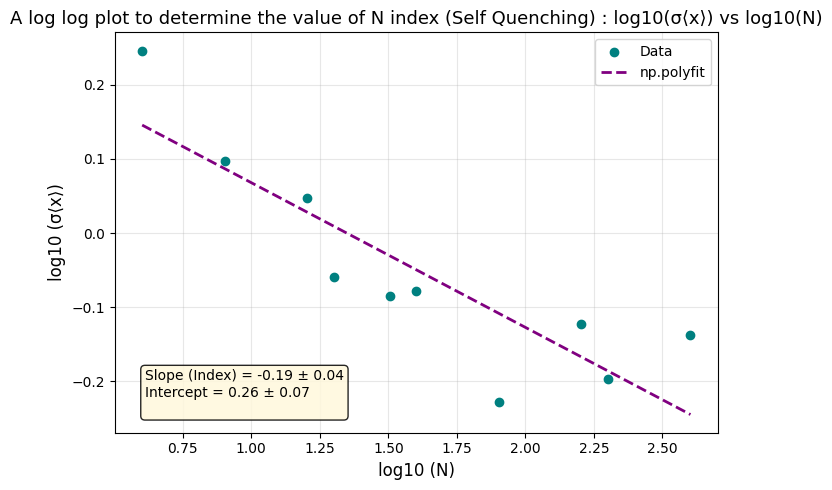

In [ ]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
t_acq = 20000/500000

signal_std = []    # σ_x (std of individual background points)
signal_noise = [] # σ<x> (Average error## =          std/sqrt(N))
signal_noise_err = []
rep_rates = []
signal_mean_array = []

for file in filelist:
    if file.endswith(".csv") and "TA" in file:

        csv_title = file

        # --- Robust rep rate extraction ---
        match = re.search(r'TA\s+(\d+)', csv_title)
        if match:
            rep_rate = int(match.group(1))
        else:
            print(f"Skipping file (no rep rate found): {csv_title}")
            continue

        print(f"Processing: {csv_title} → rep_rate = {rep_rate}")

        # --- Load data ---
        df = pd.read_csv(
            os.path.join(pathTRAS, csv_title),
            sep=";",
            header=None,
            names=["time", "signal"]
        )

        df = df.iloc[1:].reset_index(drop=True)
        df = df.astype(float)

        # --- Background selection ---
        df_bg = df[df["time"] < -10].reset_index(drop=True)
        signal = df_bg["signal"].to_numpy()

        if len(signal) < 2:
            print(f"Skipping (not enough background points): {csv_title}")
            continue

        N = rep_rate * (t_acq) # assuming rep_rate = number of averages per point

        # --- Statistics ---
        signal_mean = np.mean(signal)
        std = np.std(signal, ddof=1)   # this is σ⟨x⟩

        N_bg = len(signal)

        std_err = std / np.sqrt(2 * (N_bg - 1))

        print(f"  N_bg={len(signal)}, mean={signal_mean:.5f}, noise={std:.5f}")

        rep_rates.append(rep_rate)
        signal_mean_array.append(signal_mean)
        signal_noise.append(std)
        signal_noise_err.append(std_err)

# --- Convert to arrays ---
rep_rates = np.array(rep_rates)
signal_mean_array = np.array(signal_mean_array)
signal_noise = np.array(signal_noise)
signal_noise_err = np.array(signal_noise_err)

# --- Sort by rep rate ---
sorted_idx = np.argsort(rep_rates)
rep_rates         = rep_rates[sorted_idx]
signal_mean_array = signal_mean_array[sorted_idx]
signal_noise = signal_noise[sorted_idx]
signal_noise_err = signal_noise_err[sorted_idx]

# --- Finley Corner ---

y = np.log10(signal_noise)
#y_err = signal_noise_err / (signal_noise * np.log(10))
x = np.log10(rep_rates*t_acq)
#plt.scatter(x,y)
#plt.show()

# model: y = A * N^(-0.5)
# model = N ** (-0.5)

# A = np.sum(y * model / y_err**2) / np.sum(model**2 / y_err**2)

# y_fit = A * model
# chi2 = np.sum(((y - y_fit) / y_err) ** 2)

# dof = len(y) - 1   # one fitted parameter (A)
# chi2_red = chi2 / dof

# print(chi2_red)

###


coeffs, cov = np.polyfit(x, y, 1, cov = True)

slope = coeffs[0]
intercept = coeffs[1]

slope_err = np.sqrt(cov[0, 0])
intercept_err = np.sqrt(cov[1, 1])




coeffs = np.polyfit(x, y, 1)

x_fit = np.linspace(min(x), max(x), 100)

fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(x, y,
           color='teal', zorder=5, label='Data')

ax.plot(x_fit, coeffs[0]*x_fit + coeffs[1], color='purple', linestyle='dashed', linewidth=2, markersize=7, label=f'np.polyfit')

ax.set_xlabel('log10 (N)', fontsize=12)
ax.set_ylabel('log10 (σ⟨x⟩)', fontsize=12)
ax.set_title('A log log plot to determine the value of N index (Self Quenching) : log10(σ⟨x⟩) vs log10(N)', fontsize=13)

ax.legend()
ax.grid(True, alpha=0.3)

ax.text(0.05, 0.1,
        f"Slope (Index) = {slope:.2f} ± {slope_err:.2f}\n"
        f"Intercept = {intercept:.2f} ± {intercept_err:.2f}\n",
        transform=ax.transAxes,
        fontsize=10,
        verticalalignment='center',
        bbox=dict(boxstyle="round", facecolor="cornsilk", alpha=0.85))

plt.tight_layout()
plt.savefig(os.path.join(pathTRAS, "Graph_Rep_Rate_Self.png"),
    dpi=300, bbox_inches="tight")

#print('Index value =',slope,'Uncert =',slope_err)

## Fitting an exponential